# M33 notebook 2b: save list of peaks

This notebook will have to be run separately for each field. 

Get maps for the different background box sizes. Then define the threshold for the peaks (depends on bg box size, noise, SNR). Look at plot of map of peaks. If satisfied with the detection, save this list of peaks as a csv file.


In [1]:
field = 'SW'


In [2]:
# Parameters
field = "F8"


In [3]:
%matplotlib inline

import numpy as np
import astropy.io.fits as fits
#from scipy.ndimage import median_filter, uniform_filter, minimum_filter, maximum_filter, convolve, standard_deviation
from scipy.ndimage import median_filter, uniform_filter, standard_deviation
from scipy.ndimage import gaussian_laplace
from scipy.ndimage import generic_filter
import scipy.ndimage as ndimage
from scipy import stats

from astropy.table import QTable
from astropy.table import Table
import sys
import json
import os

# import orb as orb
# from orcs.process import SpectralCube
# import orb.utils.image

from time import perf_counter as clock
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
def readdata(file):
    data,hdr = fits.getdata(file,header=True)
    print('Reading: ',file,data.shape)
    return data,hdr

    
def makeplot(log,col,imagein,imagevvi,xi,xf,yi,yf,a,vvimin,vvimax,cbartit):
    plt.rcParams['axes.linewidth'] = 2
    plt.tick_params(axis='both', direction='in',   labelsize=20, length=6, width=2)
    plt.axis([xi,xf,yi,yf])
    if col != 0: couleur = 'rainbow'
    if col == 0: couleur = 'gray'
    if log == 1: 
        vvi=np.log10(imagevvi[yi:yf,xi:xf])
        plt.imshow(np.log10(imagein), cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    if log != 1: 
        vvi=imagevvi[yi:yf,xi:xf]
        plt.imshow(imagein, cmap=couleur, origin='lower',alpha=a,
                   vmin=np.nanpercentile(vvi,vvimin),vmax=np.nanpercentile(vvi,vvimax)) 
    cbar=plt.colorbar(pad=0.01)
    cbar.ax.tick_params(labelsize=20)
    if cbartit != '': cbar.set_label(cbartit, size=25)
    return

In [5]:
# xi, xf, yi, yf = np.array(data_paths_dict['Image portion xi,xf,yi,yf'])
sizebox = 1

xi,xf,yi,yf = np.loadtxt(f'peak_files/param_sections/param_section_{sizebox}_{field}.txt', unpack=True)
#convert to int
xi,xf,yi,yf = int(xi), int(xf), int(yi), int(yf)

print('Image portion XY:', xi,xf,yi,yf)


directory = '../M33-Maps/M33-{}/'.format(field)

print()
print('SN3: ')
im_amp,header3 = readdata(directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits'.format(field))
im_amp_noi,hea = readdata(directory+'M33-{}_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits'.format(field))

# im_amp,header3 = readdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude.fits'.format(field))
# im_amp_noi,hea = readdata(directory+'M33-{}_SN3.LineMaps.map.6563.1x1.amplitude-err.fits'.format(field))

im_amp_snr = im_amp/im_amp_noi
maskbg3,hea    = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/SNR3.fits')
starvalue      = 0
print('Starvalue = ', starvalue)
im_amp_s       = np.copy(im_amp)
im_amp_s[maskbg3 == starvalue] = np.nan
im_amp_snr_s       = np.copy(im_amp_snr)
im_amp_snr_s[maskbg3 == starvalue] = np.nan
print('Amplitude file with stars = nan')
fluxha,hdr = readdata(directory+'M33{}-Haflux.fits'.format(field))
fluxha[maskbg3 == starvalue] = np.nan 


print()
im_amp3_s,hea       = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/AMP_sizd{sizebox}.fits') # 5x5 and Stars are nan
im_amp3_m,hea       = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/M33_{field}_HaOIII_amp_nonan.fits') # 5x5 and Stars are median
im_amp3_snr_s,hea   = readdata(f'peak_files/data_for_visualisation_OIII+Ha_{field}/SNR3.fits')

print()

file = f'peak_files/data_for_visualisation_OIII+Ha_{field}/A_PicL17_sizd{sizebox}.fits'
im_pic, hea = readdata(file)
ypic,xpic = np.where(im_pic == 1)
npic = len(xpic)
idpic = np.arange(0,len(xpic),1)
idpic = np.array(idpic)
print('Nb pic in detection fits file ',file,': ',len(xpic))

print()
Folder_data = f'peak_files/2-BG_Noi_Th_data_OIII+Ha_{field}/'
if os.path.isdir(Folder_data) == False:
    os.mkdir(Folder_data)
    print('Folder created: ', Folder_data)
else:
    print('Folder exists already: ', Folder_data)

Folder_fig = f'peak_files/2-BG_Noi_Th_fig_OIII+Ha_{field}/'
if os.path.isdir(Folder_fig) == False:
    os.mkdir(Folder_fig)
    print('Folder created: ', Folder_fig)
else:
    print('Folder exists already: ', Folder_fig)

Image portion XY: 50 2000 50 2000

SN3: 
Reading:  ../M33-Maps/M33-F8/M33-F8_SN3.LineMaps.map.Ha+OIII.1x1.amplitude.fits (2064, 2048)
Reading:  ../M33-Maps/M33-F8/M33-F8_SN3.LineMaps.map.Ha+OIII.1x1.amplitude-err.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F8/SNR3.fits (2064, 2048)
Starvalue =  0
Amplitude file with stars = nan
Reading:  ../M33-Maps/M33-F8/M33F8-Haflux.fits (2064, 2048)

Reading:  peak_files/data_for_visualisation_OIII+Ha_F8/AMP_sizd1.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F8/M33_F8_HaOIII_amp_nonan.fits (2064, 2048)
Reading:  peak_files/data_for_visualisation_OIII+Ha_F8/SNR3.fits (2064, 2048)

Reading:  peak_files/data_for_visualisation_OIII+Ha_F8/A_PicL17_sizd1.fits (2064, 2048)
Nb pic in detection fits file  peak_files/data_for_visualisation_OIII+Ha_F8/A_PicL17_sizd1.fits :  101226

Folder created:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/
Folder created:  peak_files/2-BG_Noi_Th_fig_OIII+Ha_F8/


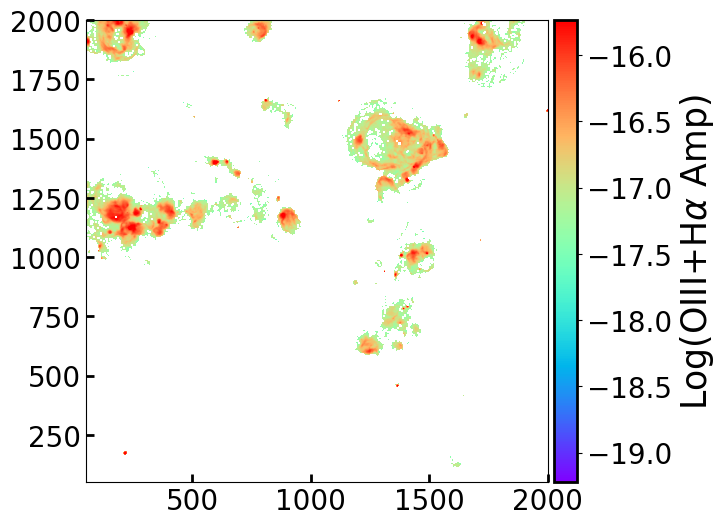

In [6]:
nyy, nxx, ip = 1,1,0
fig1 = plt.figure(figsize=(8*nxx,6*nyy))
fig1.subplots_adjust(hspace=0.2,wspace=0.1)
ip=ip+1
ax=plt.subplot(nyy,nxx,ip)
makeplot(1,1,im_amp_s,im_amp_s,xi,xf,yi,yf,1,1,99.9,cbartit=r'Log(OIII+H$\alpha$ Amp)')
#fig1.savefig(Folder_fig+'Amp_boxes.jpeg',bbox_inches = 'tight')


In [7]:
print(f"[CHECKPOINT] Starting threshold maps calculation (~2 mins)", flush=True)

#BG box
allbgbox = np.arange(30,40,10) # more than needed, no fraction
# allbgbox = [35]
# Just have an idea of the nb peaks above BG (not Th) using various limits of the SNR3
allsnr   = np.arange(5,7,1) 
npic_bgsnr = np.zeros([len(allbgbox),len(allsnr)])
print(npic_bgsnr.shape)

data_table = QTable( names = ['BGBox','SNRlim','Npic'])

t = clock()
for ib in range(len(allbgbox)):
    im_bg = np.copy(im_amp3_m)
    im_bg[yi:yf,xi:xf] = median_filter(im_amp3_m[yi:yf,xi:xf],size=allbgbox[ib])
    #im_bg[starmask3 == starvalue] = np.nan
    fits.writeto(f'{Folder_data}BG3_sizbg{allbgbox[ib]}.fits', im_bg, header3, overwrite=True)
    print('BG box : ', allbgbox[ib] ,'%.2f seconds' %(clock()-t)) 

    im_bg[maskbg3 == starvalue] = np.nan
    im_picbg = np.copy(im_pic)
    im_picbg[im_amp3_s < im_bg] = np.nan
    for ir in range(len(allsnr)):
        im_picbg[im_amp3_snr_s < allsnr[ir]]    = np.nan
        ypicsnr,xpicsnr = np.where(im_picbg == 1)
        npic_bgsnr[ib,ir] = len(ypicsnr)
        print('   SNR:',allsnr[ir],' npic=',npic_bgsnr[ib,ir])
        data_table.add_row([allbgbox[ib],allsnr[ir],npic_bgsnr[ib,ir]])
        
print('All done')

data_table.write(Folder_data+'BGbox_SNRlim_Npic.ascii', overwrite=True, format='ascii')                 

[CHECKPOINT] Starting threshold maps calculation (~2 mins)


(1, 2)


BG box :  30 23.39 seconds
   SNR: 5  npic= 4766.0
   SNR: 6  npic= 3660.0
All done


In [8]:
# #### BG to see  - stars are set to nan in plots

# %matplotlib inline
# xc,yc,sizpl =1000,700,200 #1260, 1247, 50 #1125,900, 50 #xcen[9],ycen[9],50 #750,800,50
# x1,x2,y1,y2 = xc-sizpl,xc+sizpl+1,yc-sizpl,yc+sizpl+1 

# nyy, nxx, ip = 10,3,0
# fig1 = plt.figure(figsize=(8*nxx,6*nyy))
# fig1.subplots_adjust(hspace=0.2,wspace=0.1)


# for bgbox in [40,50,60,70,80,90]:
#     file = f'{Folder_data}BG3_sizbg{bgbox}.fits'
#     im_bg = fits.getdata(file)
#     im_bg[maskbg3 == starvalue] = np.nan
#     ip=ip+1
#     ax=plt.subplot(nyy,nxx,ip)
#     imagein = im_amp3_s - im_bg
#     makeplot(1,1,imagein,im_amp3_s,x1,x2,y1,y2,1,1,99.9,cbartit='Difference')
#     plt.plot(xpic,ypic,'o',color='black',ms=3)
#     ip=ip+1
#     ax=plt.subplot(nyy,nxx,ip)
#     makeplot(1,1,im_bg,im_amp3_s,x1,x2,y1,y2,1,1,99.9,cbartit='BG box: '+str(bgbox))
#     ip=ip+1
#     ax=plt.subplot(nyy,nxx,ip)
#     makeplot(1,1,im_amp3_s,im_amp3_s,x1,x2,y1,y2,1,1,99.9,cbartit=r'Log(H$\alpha$ Amp3)')
#     plt.plot(xpic,ypic,'o',color='black',ms=3)

# fig1.savefig(Folder_fig+'BGbox.jpeg',bbox_inches = 'tight')

# ### i.e. larger box  = more peak when croaded
# ### i.e. smaller box = more peak when isolated
# ### so a good idea to combine more than one threshold...

In [9]:
print(f"[CHECKPOINT] Starting noise maps calculation (~3 mins)", flush=True)
# noise map for individual thereshole

# allbgbox = [35]
allstdbox = [3]   # 3 = seeing 

for bgbox in allbgbox: 
    file   = f'peak_files/2-BG_Noi_Th_data_OIII+Ha_{field}/BG3_sizbg{bgbox}.fits'
    im_bgnoi  = fits.getdata(file)
    print('Spatial noise with BG3 :',file,)
    #print('Min, max, med BG : ',np.nanmin(im_bgnoi),np.nanmax(im_bgnoi),np.nanmedian(im_bgnoi))
    im_res =  im_amp3_m  - im_bgnoi 
    #print('Min, max, med Res: ',np.nanmin(im_res),np.nanmax(im_res),np.nanmedian(im_res))
    
    for stdbox in allstdbox: 
        t = clock()
        im_noi = np.copy(im_res)
        im_noi[yi:yf,xi:xf] = generic_filter(im_res[yi:yf,xi:xf],np.nanstd,size=(stdbox,stdbox))
        #print('Min, max, med STD: ',np.nanmin(im_noi),np.nanmax(im_noi),np.nanmedian(im_noi))
        fits.writeto(f'{Folder_data}Noi_box{bgbox}_std{stdbox}.fits', im_noi, header3, overwrite=True)
        print('   Noi : ', bgbox, stdbox ,'%.2f seconds' %(clock()-t)) 

print('Done')


[CHECKPOINT] Starting noise maps calculation (~3 mins)


Spatial noise with BG3 : peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/BG3_sizbg30.fits


   Noi :  30 3 52.35 seconds
Done


In [10]:
# Threshold with various signoi for 2045 or 1045

# allbgbox = [35]
# allstdbox = [3]
allsignoi = np.arange(1,5,.5)


## 1) BG
for bgbox in allbgbox:
    file   = f'peak_files/2-BG_Noi_Th_data_OIII+Ha_{field}/BG3_sizbg{bgbox}.fits'
    im_bg  = fits.getdata(file)
    print('BG3 file   : ',file)
  
## 2) Noise
    for stdbox in allstdbox: # 3 = seeing
        file   = f'peak_files/2-BG_Noi_Th_data_OIII+Ha_{field}/Noi_box{bgbox}_std{stdbox}.fits'
        im_noi  = fits.getdata(file)
        print('  Noise file    : ',file)
        
    ## 3) Threshold
        for signoi in allsignoi: 
            im_th = im_bg + (signoi*im_noi)
            file = f'{Folder_data}Th_box{bgbox}_std{stdbox}_signoi{np.round(signoi,1)}.fits'
            fits.writeto(file, im_th, header3, overwrite=True)
            print('    Thresh. file: ',file)

print('Done')

BG3 file   :  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/BG3_sizbg30.fits
  Noise file    :  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Noi_box30_std3.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi1.0.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi1.5.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi2.0.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi2.5.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi3.0.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi3.5.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi4.0.fits
    Thresh. file:  peak_files/2-BG_Noi_Th_data_OIII+Ha_F8/Th_box30_std3_signoi4.5.fits
Done
